# Heart Disease Risk Prediction — PyTorch ANN with SQL Pipeline

## Project Overview
End-to-end heart disease prediction system built on 630,000 patient records.  
Combines **SQLite3 data pipeline**, **feature engineering**, and a **PyTorch ANN** 
to predict heart disease risk with ROC-AUC of 0.9537.

**Tech Stack:** Python, PyTorch, SQLite3, Scikit-Learn, Pandas, Seaborn

## 1. Libraries & Setup
Importing all required libraries for data processing, visualization, ML and deep learning.

In [76]:
import numpy as np
import pandas as pd
import sqlite3
import warnings
import prettytable
warnings.filterwarnings('ignore')
prettytable.DEFAULT = 'DEFAULT'

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn — Preprocessing
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Sklearn — Model Selection
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

# Sklearn — Baseline Model
from sklearn.linear_model import LogisticRegression

# Sklearn — Evaluation
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

# Model Saving
import joblib

## 2. Data Loading & SQLite Setup
Loading the heart disease dataset into a SQLite database and connecting SQL magic 
for EDA queries. This simulates a real-world database-driven data pipeline.

In [2]:
conn = sqlite3.connect('heart.db')
%load_ext sql

In [3]:
df = pd.read_csv("heart_disease_dataset.xls")

In [4]:
df.to_sql(name="Heart_datatable", con=conn, if_exists="replace", index=False)

630000

In [5]:
%sql sqlite:///heart.db

In [6]:
%sql SELECT COUNT(*) FROM Heart_datatable;

 * sqlite:///heart.db
Done.


COUNT(*)
630000


In [7]:
%sql SELECT * FROM Heart_datatable LIMIT 5;

 * sqlite:///heart.db
Done.


id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


## 3. Exploratory Data Analysis (SQL)
Performing comprehensive EDA using 16 SQL queries covering:
- Dataset overview and class distribution
- Demographic analysis (Age, Sex)
- Clinical feature analysis (Cholesterol, BP, Max HR)
- Multi-factor risk combinations
- Final risk summary by Chest Pain Type

In [8]:
%%sql
SELECT 
    COUNT(*) as total_patients,
    SUM(CASE WHEN "Heart Disease" = 'Presence' THEN 1 ELSE 0 END) as disease_cases,
    SUM(CASE WHEN "Heart Disease" = 'Absence' THEN 1 ELSE 0 END) as absence_cases,
    ROUND(SUM(CASE WHEN "Heart Disease" = 'Presence' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) as disease_rate_pct
FROM Heart_datatable;

 * sqlite:///heart.db
Done.


total_patients,disease_cases,absence_cases,disease_rate_pct
630000,282454,347546,44.83


In [9]:
%%sql 
PRAGMA table_info(Heart_datatable)

 * sqlite:///heart.db
Done.


cid,name,type,notnull,dflt_value,pk
0,id,INTEGER,0,None,0
1,Age,INTEGER,0,None,0
2,Sex,INTEGER,0,None,0
3,Chest pain type,INTEGER,0,None,0
4,BP,INTEGER,0,None,0
5,Cholesterol,INTEGER,0,None,0
6,FBS over 120,INTEGER,0,None,0
7,EKG results,INTEGER,0,None,0
8,Max HR,INTEGER,0,None,0
9,Exercise angina,INTEGER,0,None,0


In [78]:
%%sql
SELECT 
    COUNT(DISTINCT Sex) as Sex_distinct,
    COUNT(DISTINCT "Chest pain type") as ChestPain_distinct,
    COUNT(DISTINCT "EKG results") as EKG_distinct,
    COUNT(DISTINCT "Exercise angina") as ExerciseAngina_distinct,
    COUNT(DISTINCT "Slope of ST") as SlopeOfST_distinct,
    COUNT(DISTINCT "Number of vessels fluro") as Vessels_distinct,
    COUNT(DISTINCT Thallium) as Thallium_distinct,
    COUNT(DISTINCT "Heart Disease") as Target_distinct
FROM Heart_datatable;

 * sqlite:///heart.db
Done.


Sex_distinct,ChestPain_distinct,EKG_distinct,ExerciseAngina_distinct,SlopeOfST_distinct,Vessels_distinct,Thallium_distinct,Target_distinct
2,4,3,2,3,4,3,2


In [10]:
%%sql 
SELECT 
SUM(CASE WHEN "Heart Disease" = 'Presence' THEN 1 ELSE 0 END) AS DISEASE_present,
SUM(CASE WHEN "Heart Disease" = 'Absence' THEN 1 ELSE 0 END) AS DISEASE_absence,
ROUND(SUM(CASE WHEN "Heart Disease" = 'Presence' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) as disease_present_pct,
ROUND(SUM(CASE WHEN "Heart Disease" = 'Absence' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) as disease_absence_pct
FROM Heart_datatable;


 * sqlite:///heart.db
Done.


DISEASE_present,DISEASE_absence,disease_present_pct,disease_absence_pct
282454,347546,44.83,55.17


55.17% Absence vs 44.83% Presence — moderate class imbalance exists. Will handle using WeightedRandomSampler in PyTorch training.

In [11]:
%%sql 
SELECT "Heart Disease", AVG(Age)
FROM Heart_datatable
GROUP BY "Heart Disease";

 * sqlite:///heart.db
Done.


Heart Disease,AVG(Age)
Absence,52.558093029411936
Presence,56.07911376719749


Patients with Heart Disease are on average ~3.5 years older (56.08) than those without (52.56) — Age is a meaningful predictor of heart disease risk.

In [12]:
%%sql 
SELECT "Sex", ROUND(SUM(CASE WHEN "Heart Disease" = 'Presence' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) as disease_PCT
FROM Heart_datatable 
GROUP BY "Sex" ; 

 * sqlite:///heart.db
Done.


Sex,disease_PCT
0,17.88
1,55.59


Males (Sex=1) have a significantly higher heart disease rate of 55.59% compared to females (Sex=0) at just 17.88% — Sex is a strong predictor in this dataset.

In [13]:
%%sql 
SELECT
CASE WHEN "Age" < 40 THEN 'Below 40'
     WHEN "Age" < 50 THEN '40-50'
     WHEN "Age" < 60 THEN '50-60'
     WHEN "Age" >= 60 THEN 'Above 60'
END AS Age_group,
SUM(CASE WHEN "Heart Disease" = 'Presence' THEN 1 ELSE 0 END) AS presence_case 
FROM Heart_datatable
GROUP BY Age_group;

 * sqlite:///heart.db
Done.


Age_group,presence_case
40-50,48372
50-60,133352
Above 60,96163
Below 40,4567


50–60 age group has the highest heart disease cases (133,352) followed by Above 60 (96,163) — confirming age is a strong risk factor, with middle-to-older age patients being most vulnerable.

In [14]:
%%sql 
SELECT 
Sex,
CASE WHEN "Age" < 40 THEN 'Below 40'
     WHEN "Age" < 50 THEN '40-50'
     WHEN "Age" < 60 THEN '50-60'
     WHEN "Age" >= 60 THEN 'Above 60'
END AS Age_group,
SUM(CASE WHEN "Heart Disease" = 'Presence' THEN 1 ELSE 0 END) AS presence_case
FROM Heart_datatable
GROUP BY Sex, Age_group
ORDER BY Sex, Age_group;

 * sqlite:///heart.db
Done.


Sex,Age_group,presence_case
0,40-50,5694
0,50-60,15253
0,Above 60,10667
0,Below 40,513
1,40-50,42678
1,50-60,118099
1,Above 60,85496
1,Below 40,4054


Males (Sex=1) dominate heart disease cases across ALL age groups — especially in the 50-60 range with 118,099 cases vs only 15,253 for females. Both sexes peak in the 50-60 age group confirming age and sex together are strong combined risk factors.

In [15]:
%%sql 
SELECT "Heart Disease", AVG(Cholesterol), AVG(BP), AVG("Max HR") 
FROM Heart_datatable 
GROUP BY "Heart Disease";

 * sqlite:///heart.db
Done.


Heart Disease,AVG(Cholesterol),AVG(BP),"AVG(""Max HR"")"
Absence,242.49910227710865,130.56738100855713,160.4151047631105
Presence,248.10358500853235,130.41136609855056,143.46737167822016


Heart Disease patients have higher average Cholesterol (248 vs 242) but surprisingly similar BP levels. Most striking — Max HR is significantly lower in disease patients (143 vs 160), suggesting reduced cardiac capacity is a stronger indicator than BP alone.

In [16]:
%%sql
SELECT 
COUNT(*) as high_risk_patients,
SUM(CASE WHEN "Heart Disease" = 'Presence' THEN 1 ELSE 0 END) as disease_cases,
ROUND(SUM(CASE WHEN "Heart Disease" = 'Presence' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) as disease_pct
FROM Heart_datatable
WHERE Cholesterol > 240 AND BP > 140;

 * sqlite:///heart.db
Done.


high_risk_patients,disease_cases,disease_pct
52019,24958,47.98


52,019 patients have both high Cholesterol (>240) and high BP (>140). Of these high risk patients, 47.98% have heart disease — slightly higher than the overall disease rate of 44.83%, confirming that combined high cholesterol and high BP does increase heart disease risk.



In [17]:
%%sql 
SELECT "Chest pain type", 
SUM(CASE WHEN "Heart Disease" = 'Presence' THEN 1 ELSE 0 END) as disease_cases,
SUM(CASE WHEN "Heart Disease" = 'Absence' THEN 1 ELSE 0 END) as NOT_cases
FROM Heart_datatable 
GROUP BY "Chest pain type";

 * sqlite:///heart.db
Done.


Chest pain type,disease_cases,NOT_cases
1,3091,25511
2,12154,62787
3,37614,159664
4,229595,99584


Chest Pain Type 4 is the most alarming — 229,595 disease cases vs only 99,584 absence cases, making it the only type where Presence exceeds Absence. Types 1, 2, and 3 show more absence than presence. This makes Chest Pain Type a very strong predictor — Type 4 patients are at significantly higher risk.

In [77]:
%%sql
SELECT 
COUNT(*) as high_risk_patients,
ROUND(SUM(CASE WHEN "Heart Disease" = 'Presence' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) as disease_pct
FROM Heart_datatable
WHERE "Exercise Angina" = 1;

 * sqlite:///heart.db
Done.


high_risk_patients,disease_pct
172447,80.63


80.63% of patients with Exercise Angina have Heart Disease — this is the strongest single predictor found so far, nearly double the overall disease rate of 44.83%. Exercise Angina alone is a massive red flag for heart disease risk.

In [19]:
%%sql 
SELECT "Slope of ST", "Heart Disease", AVG("ST depression")
FROM Heart_datatable
GROUP BY "Slope of ST", "Heart Disease";

 * sqlite:///heart.db
Done.


Slope of ST,Heart Disease,"AVG(""ST depression"")"
1,Absence,0.2459983051360431
1,Presence,0.6458019475336562
2,Absence,0.6639350038657997
2,Presence,1.409838031107953
3,Absence,0.8036565609812543
3,Presence,1.7496732611225494


Across all Slope of ST values, Heart Disease patients consistently show higher average ST depression than Absence patients. Slope 3 with Presence has the highest ST depression (1.75) — confirming that both higher Slope of ST value and higher ST depression together strongly indicate heart disease risk.

In [20]:
%%sql
SELECT 
"Chest pain type", Thallium,
SUM(CASE WHEN "Heart Disease" = 'Presence' THEN 1 ELSE 0 END) as TOTAL_COUNT,
COUNT(*) as total_patients,
ROUND(SUM(CASE WHEN "Heart Disease" = 'Presence' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) as disease_pct
FROM Heart_datatable
GROUP BY "Chest pain type", Thallium
ORDER BY TOTAL_COUNT DESC
LIMIT 5;

 * sqlite:///heart.db
Done.


Chest pain type,Thallium,TOTAL_COUNT,total_patients,disease_pct
4,7,165611,183366,90.32
4,3,57875,138491,41.79
3,7,25484,43740,58.26
3,3,11104,151055,7.35
2,7,8005,14923,53.64


The most dangerous combination is Chest Pain Type 4 + Thallium 7 with a massive 90.32% disease rate across 183,366 patients — nearly 9 in 10 patients with this combination have heart disease. Interestingly Chest Pain Type 3 + Thallium 3 has only 7.35% disease rate despite 151,055 patients — showing Thallium value dramatically changes risk within the same chest pain type.

In [21]:
%%sql 
SELECT 
COUNT(*) AS total_patients,
"Number of Vessels Fluro",
ROUND(SUM(CASE WHEN "Heart Disease" = 'Presence' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) as disease_pct
FROM Heart_datatable 
GROUP BY "Number of Vessels Fluro";

 * sqlite:///heart.db
Done.


total_patients,Number of vessels fluro,disease_pct
445862,0,30.31
106978,1,72.93
54303,2,89.71
22857,3,89.95


Clear progressive pattern — as Number of Vessels Fluro increases, disease rate increases dramatically. 0 vessels: 30.31% vs 3 vessels: 89.95%. This is one of the strongest linear predictors in the entire dataset — more blocked vessels directly means higher heart disease risk.



In [22]:
%%sql
SELECT 
COUNT(*) as high_risk_patients,
SUM(CASE WHEN "Heart Disease" = 'Presence' THEN 1 ELSE 0 END) as disease_cases,
ROUND(SUM(CASE WHEN "Heart Disease" = 'Presence' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) as disease_pct
FROM Heart_datatable
WHERE Cholesterol > 240 AND BP > 140 AND Age > 55;

 * sqlite:///heart.db
Done.


high_risk_patients,disease_cases,disease_pct
24754,14507,58.6


24,754 patients meet all three high risk criteria (Age>55, Cholesterol>240, BP>140). 58.6% of them have heart disease — significantly higher than the overall rate of 44.83%. Being high risk on all three indicators together increases disease probability by nearly 14 percentage points.

In [23]:
%%sql 
SELECT 
"Chest pain type", AVG(Age), AVG(cholesterol), AVG("Max HR"),
ROUND(SUM(CASE WHEN "Heart Disease" = 'Presence' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) as disease_pct
FROM Heart_datatable
GROUP BY "Chest pain type"
ORDER BY disease_pct DESC
LIMIT 5;

 * sqlite:///heart.db
Done.


Chest pain type,AVG(Age),AVG(cholesterol),"AVG(""Max HR"")",disease_pct
4,55.12167240316059,246.6295602088833,148.22332834111532,69.75
3,53.105820213100294,243.4236204746601,157.52843195896148,19.07
2,53.05436276537543,243.01817429711372,158.19016292817017,16.22
1,52.74704566114258,242.57118383329836,159.10534228375639,10.81


Chest Pain Type 4 is clearly the highest risk group — oldest average age (55.12), highest cholesterol (246.63), lowest Max HR (148.22) and by far the highest disease rate (69.75%). A clear pattern emerges across all types — as disease rate increases, average age and cholesterol go up while Max HR goes down. This final summary confirms that Chest Pain Type, Age, Cholesterol and Max HR together paint a strong picture of heart disease risk

## 4. Visualizations
Key findings from EDA visualized using Seaborn and Matplotlib.  
Includes correlation heatmap and boxplots to inform preprocessing decisions.

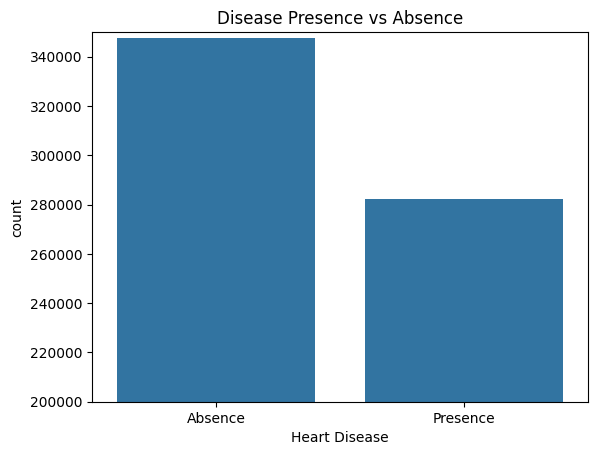

In [24]:
df_plot = pd.read_sql_query("""
    SELECT "Heart Disease", COUNT(*) as count
    FROM Heart_datatable
    GROUP BY "Heart Disease"
""", conn)

sns.barplot(data=df_plot, x="Heart Disease", y="count")
plt.title("Disease Presence vs Absence")
plt.ylim(200000, 350000)
plt.show()

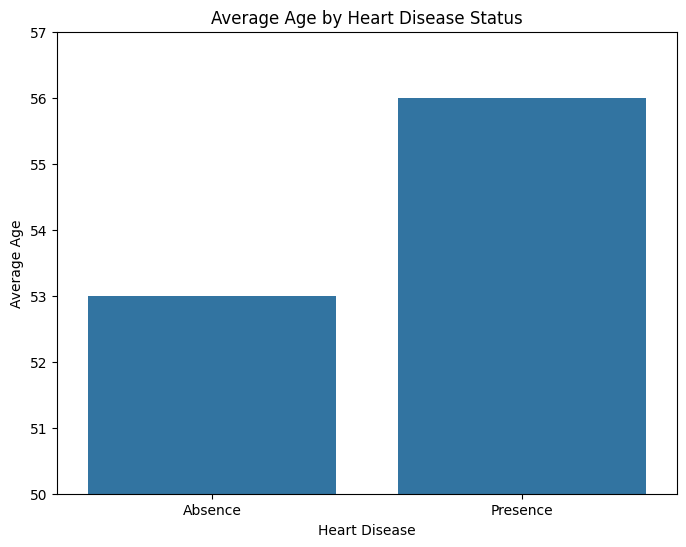

In [25]:
age_disease_data = pd.read_sql_query("""SELECT "Heart Disease", ROUND(AVG(Age)) AS avg_age
FROM Heart_datatable 
GROUP BY "Heart Disease";""", conn)

plt.figure(figsize=(8,6))
sns.barplot(data= age_disease_data, x= "Heart Disease", y= "avg_age")
plt.title("Average Age by Heart Disease Status")
plt.xlabel("Heart Disease")
plt.ylabel("Average Age")
plt.ylim(50, 57)
plt.show()

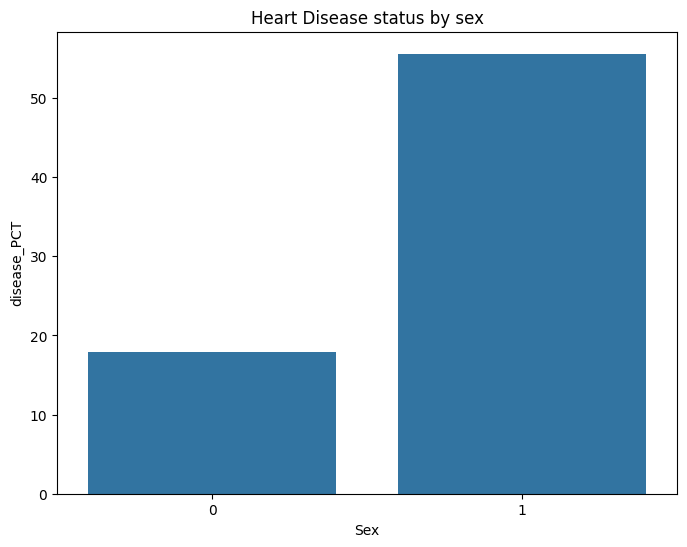

In [26]:
disease_by_sex = pd.read_sql_query("""SELECT "Sex", ROUND(SUM(CASE WHEN "Heart Disease" = 'Presence' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) as disease_PCT
FROM Heart_datatable 
GROUP BY "Sex" ; """,conn)

plt.figure(figsize=(8,6))
sns.barplot(data= disease_by_sex, x= "Sex", y= "disease_PCT")
plt.title("Heart Disease status by sex")
plt.show()

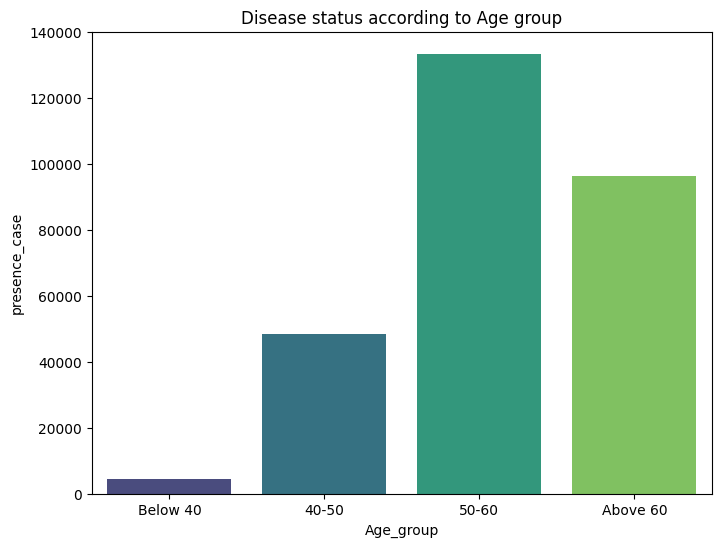

In [27]:
age_group_disease = pd.read_sql_query("""SELECT
CASE WHEN "Age" < 40 THEN 'Below 40'
     WHEN "Age" < 50 THEN '40-50'
     WHEN "Age" < 60 THEN '50-60'
     WHEN "Age" >= 60 THEN 'Above 60'
END AS Age_group,
SUM(CASE WHEN "Heart Disease" = 'Presence' THEN 1 ELSE 0 END) AS presence_case 
FROM Heart_datatable
GROUP BY Age_group;""", conn)

plt.figure(figsize=(8,6))
order = ['Below 40', '40-50', '50-60', 'Above 60']
sns.barplot(data=age_group_disease, x="Age_group", y="presence_case", palette="viridis", order= order)
plt.title("Disease status according to Age group")
plt.show()

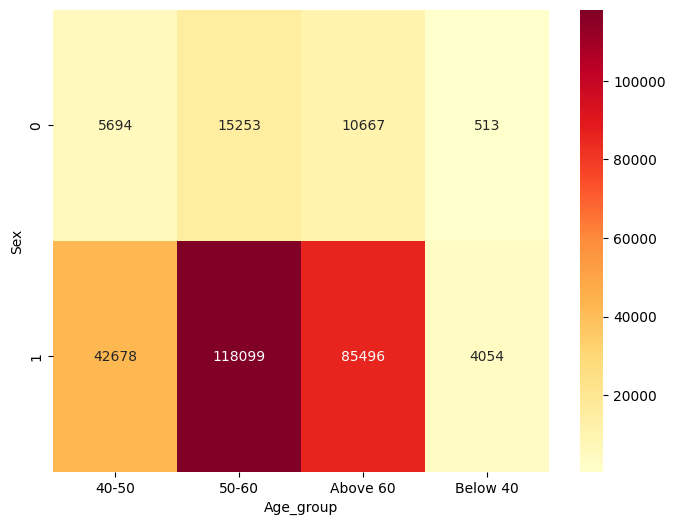

In [28]:
sex_age_disease = pd.read_sql_query("""SELECT 
Sex,
CASE WHEN "Age" < 40 THEN 'Below 40'
     WHEN "Age" < 50 THEN '40-50'
     WHEN "Age" < 60 THEN '50-60'
     WHEN "Age" >= 60 THEN 'Above 60'
END AS Age_group,
SUM(CASE WHEN "Heart Disease" = 'Presence' THEN 1 ELSE 0 END) AS presence_case
FROM Heart_datatable
GROUP BY Sex, Age_group
ORDER BY Sex, Age_group;""", conn)

pivot = sex_age_disease.pivot(index= "Sex", columns= "Age_group", values= "presence_case")

plt.figure(figsize=(8,6))
sns.heatmap(data= pivot, annot= True, fmt='d', cmap='YlOrRd')
plt.show()

Males aged 50-60 (118,099) and Above 60 (85,496) are the darkest cells — confirming the highest concentration of heart disease cases. Females remain light across all age groups showing significantly lower risk overall.

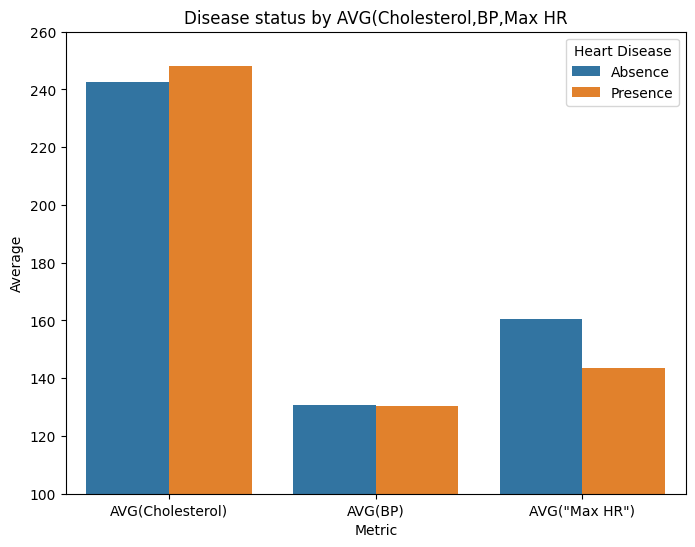

In [29]:
main_feature_plotdata = pd.read_sql_query(""" SELECT "Heart Disease", AVG(Cholesterol), AVG(BP), AVG("Max HR") 
FROM Heart_datatable 
GROUP BY "Heart Disease";""", conn)

df_melted = main_feature_plotdata.melt(id_vars="Heart Disease", 
                           var_name="Metric", 
                           value_name="Average")

plt.figure(figsize=(8,6))
sns.barplot(data=df_melted, x="Metric", y="Average", hue="Heart Disease")
plt.title("Disease status by AVG(Cholesterol,BP,Max HR")
plt.ylim(100, 260)
plt.show()

Cholesterol and BP show similar values between Presence and Absence patients. But Max HR tells the real story — Absence patients have significantly higher Max HR (160) vs Presence (143), confirming reduced cardiac capacity is a stronger indicator than cholesterol or BP alone.

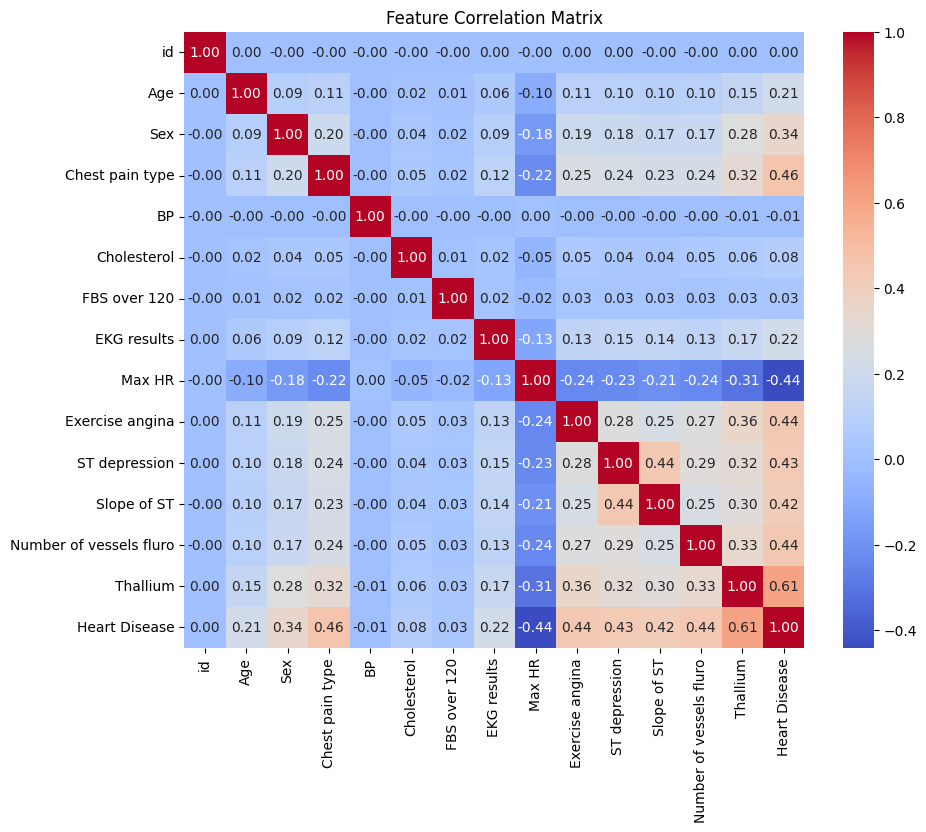

In [30]:
df_corr = pd.read_sql_query("SELECT * FROM Heart_datatable", conn)
df_corr['Heart Disease'] = (df_corr['Heart Disease'] == 'Presence').astype(int)

plt.figure(figsize=(10,8))
sns.heatmap(df_corr.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

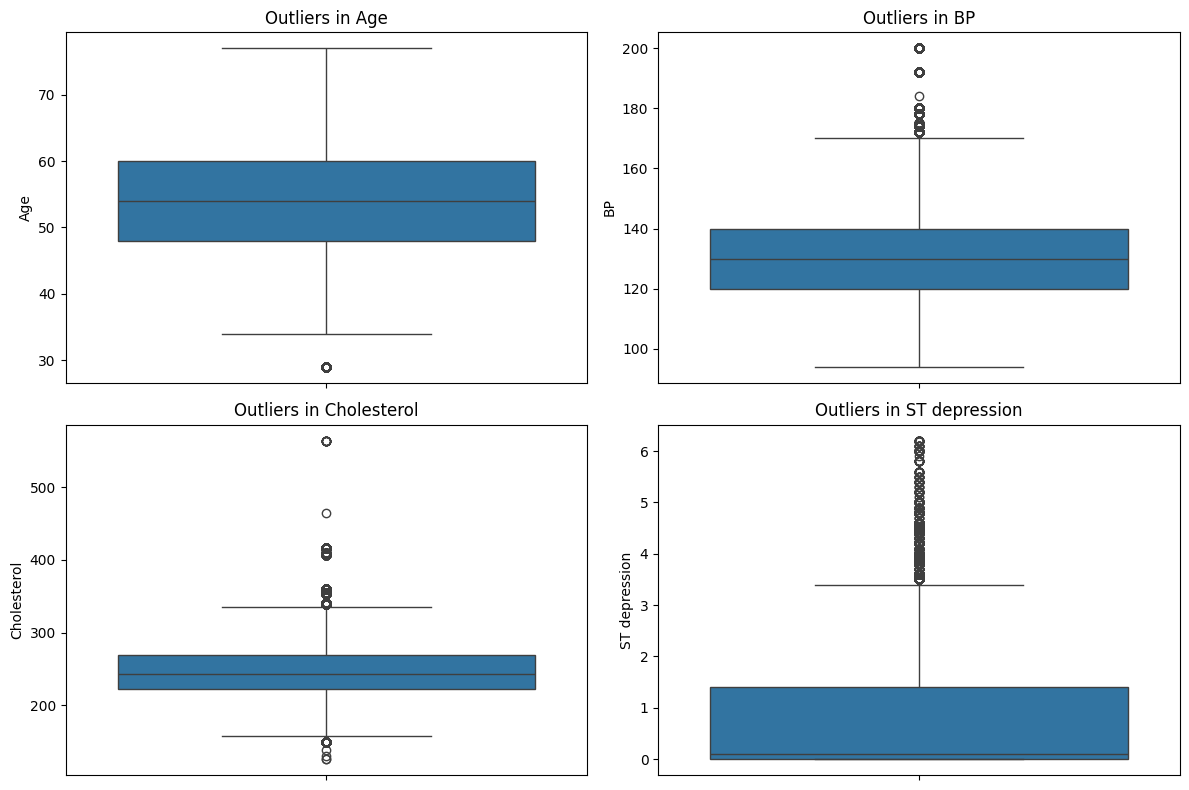

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), ['Age', 'BP', 'Cholesterol', 'ST depression']):
    sns.boxplot(data=df_corr, y=col, ax=ax)
    ax.set_title(f'Outliers in {col}')
plt.tight_layout()
plt.show()

## 5. Feature Engineering & Preprocessing
- Dropped zero-correlation features: `BP` and `FBS over 120`
- Engineered 3 domain features: age-to-MaxHR ratio, cholesterol-to-age ratio, MaxHR×ST depression interaction
- Applied `ColumnTransformer`: `PowerTransformer` for skewed columns, `StandardScaler` for normal columns
- `stratify=y` ensures class distribution is maintained in train/test split

In [32]:
df = pd.read_sql_query("SELECT * FROM Heart_datatable", conn)
df = df.drop(columns=['id'])
df["Heart Disease"] = df["Heart Disease"].map({'Presence' : 1, 'Absence' : 0})

In [34]:
df["age_maxHR_ratio"] = df["Age"]/df["Max HR"]
df["chol_age_ratio"] = df["Cholesterol"] / df["Age"]
df["maxhr_st_interaction"] = df["Max HR"] * df["ST depression"]

In [36]:
df = df.drop(columns= ['FBS over 120', 'BP'])

In [38]:
X = df.drop(columns= ['Heart Disease'])
y = df['Heart Disease']

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42, stratify= y)

In [40]:
power_columns = ['ST depression', 'Cholesterol', 'chol_age_ratio']
standard_columns = ['Age', 'Max HR','age_maxHR_ratio', 'maxhr_st_interaction']

In [41]:
preprocessor = ColumnTransformer(transformers=[
    ('power', PowerTransformer(), power_columns),
    ('standard', StandardScaler(), standard_columns)
], remainder= 'passthrough')

In [42]:
X_train_scale = preprocessor.fit_transform(X_train)
X_test_scale = preprocessor.transform(X_test)

## 6. Baseline Model — Logistic Regression
Training a Logistic Regression baseline to benchmark against the ANN.  
Any improvement in the ANN must beat this baseline to justify added complexity.

In [43]:
lr_model = LogisticRegression(class_weight= 'balanced', random_state= 42)

In [44]:
lr_model.fit(X_train_scale, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [45]:
y_pred = lr_model.predict(X_test_scale)

In [47]:
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, lr_model.predict_proba(X_test_scale)[:,1]))

              precision    recall  f1-score   support

           0       0.90      0.89      0.89     69509
           1       0.87      0.88      0.87     56491

    accuracy                           0.88    126000
   macro avg       0.88      0.88      0.88    126000
weighted avg       0.88      0.88      0.88    126000

ROC-AUC: 0.9515126016545271


Logistic Regression baseline achieves 88% accuracy and ROC-AUC of 0.95 — a very strong baseline. Our PyTorch ANN must beat this to justify the added complexity.

## 7. PyTorch ANN Architecture
3-layer ANN with:
- **BatchNorm** for training stability
- **Dropout** to prevent overfitting
- **WeightedRandomSampler** to handle class imbalance
- **Sigmoid** output for binary classification probability

In [48]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [50]:
#converting data into tensor 
X_train_tensor = torch.FloatTensor(X_train_scale).to(device)
X_test_tensor = torch.FloatTensor(X_test_scale).to(device)

y_train_tensor = torch.FloatTensor(y_train.values).to(device)
y_test_tensor = torch.FloatTensor(y_test.values).to(device)

In [52]:
class HeartDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [54]:
train_dataset = HeartDataset(X_train_tensor, y_train_tensor)
test_dataset = HeartDataset(X_test_tensor, y_test_tensor)

In [55]:
class_counts = torch.bincount(y_train_tensor.long())
class_weights = 1.0 / class_counts.float()
sample_weights = class_weights[y_train_tensor.long()]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

In [56]:
train_loader = DataLoader(
    train_dataset,
    batch_size=256,
    sampler=sampler
)

test_loader = DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False  
)

In [57]:
class HeartModel(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.network(x)

In [64]:
model = HeartModel(input_size=14).to(device)
print(model)

HeartModel(
  (network): Sequential(
    (0): Linear(in_features=14, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=32, out_features=1, bias=True)
    (9): Sigmoid()
  )
)


In [65]:
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [66]:
#defining early stopping 
best_val_loss = float('inf')
patience = 5
patience_counter = 0
best_model_state = None

## 8. Model Training
Training with early stopping (patience=5) to prevent overfitting.  
Best model state saved and restored automatically when validation loss stops improving.

In [67]:
epochs = 50
train_losses = []
val_losses = []

for epoch in range(epochs):
    # ---- Training ----
    model.train()
    train_loss = 0
    
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        output = model(X_batch).squeeze()
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    # ---- Validation ----
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            output = model(X_batch).squeeze()
            loss = criterion(output, y_batch)
            val_loss += loss.item()
    
    # ---- Average losses ----
    train_loss /= len(train_loader)
    val_loss /= len(test_loader)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    
    # ---- Early Stopping ----
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict().copy()
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

# Load best model
model.load_state_dict(best_model_state)

Epoch 1/50 | Train Loss: 0.2971 | Val Loss: 0.2770
Epoch 2/50 | Train Loss: 0.2878 | Val Loss: 0.2762
Epoch 3/50 | Train Loss: 0.2857 | Val Loss: 0.2736
Epoch 4/50 | Train Loss: 0.2854 | Val Loss: 0.2761
Epoch 5/50 | Train Loss: 0.2857 | Val Loss: 0.2739
Epoch 6/50 | Train Loss: 0.2848 | Val Loss: 0.2742
Epoch 7/50 | Train Loss: 0.2852 | Val Loss: 0.2753
Epoch 8/50 | Train Loss: 0.2839 | Val Loss: 0.2753
Early stopping at epoch 8


<All keys matched successfully>

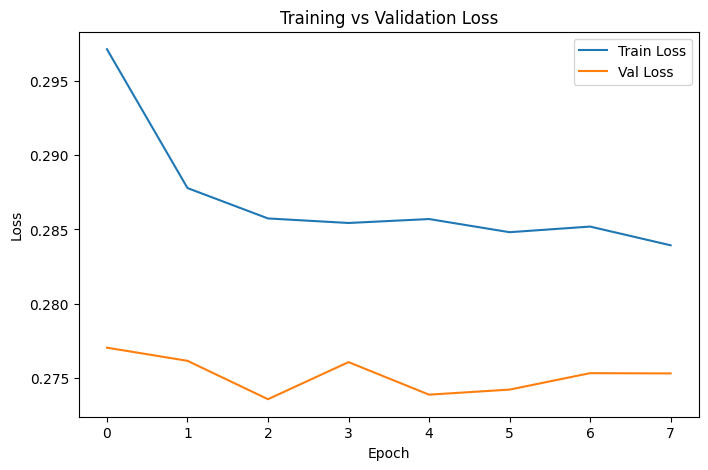

In [68]:
plt.figure(figsize=(8,5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

In [69]:
model.eval()
all_preds = []
all_probs = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        probs = model(X_batch).squeeze()
        all_probs.extend(probs.cpu().numpy())

all_probs = np.array(all_probs)
all_preds = (all_probs >= 0.5).astype(int)

## 9. Evaluation & Results

| Metric | Logistic Regression | PyTorch ANN |
|--------|-------------------|-------------|
| Accuracy | 88% | **89%** |
| ROC-AUC | 0.9515 | **0.9537** |
| Recall (Disease) | 0.88 | **0.91** |

**Threshold 0.4 selected** — in medical diagnosis, missing a disease patient (false negative) 
is far more dangerous than a false alarm. Optimising for recall minimises missed diagnoses.

In [70]:
print("ANN Classification Report:")
print(classification_report(y_test, all_preds))
print("ROC-AUC:", roc_auc_score(y_test, all_probs))

ANN Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.89      0.90     69509
           1       0.86      0.88      0.87     56491

    accuracy                           0.89    126000
   macro avg       0.88      0.89      0.88    126000
weighted avg       0.89      0.89      0.89    126000

ROC-AUC: 0.9536604041545246


ANN outperforms Logistic Regression baseline — ROC-AUC improved from 0.9515 to 0.9536 and accuracy from 88% to 89%. While the improvement is modest, the ANN captures non-linear patterns the baseline cannot.

In [71]:
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

for thresh in thresholds:
    preds = (all_probs >= thresh).astype(int)
    recall = classification_report(y_test, preds, output_dict=True)['1']['recall']
    precision = classification_report(y_test, preds, output_dict=True)['1']['precision']
    print(f"Threshold: {thresh} | Precision: {precision:.3f} | Recall: {recall:.3f}")

Threshold: 0.3 | Precision: 0.800 | Recall: 0.934
Threshold: 0.4 | Precision: 0.836 | Recall: 0.910
Threshold: 0.5 | Precision: 0.864 | Recall: 0.884
Threshold: 0.6 | Precision: 0.889 | Recall: 0.852
Threshold: 0.7 | Precision: 0.914 | Recall: 0.811


Threshold 0.4 selected — achieves 91% recall meaning only 9% of actual heart disease patients are missed. In medical diagnosis the cost of a false negative far outweighs a false alarm, justifying the slight precision trade-off.

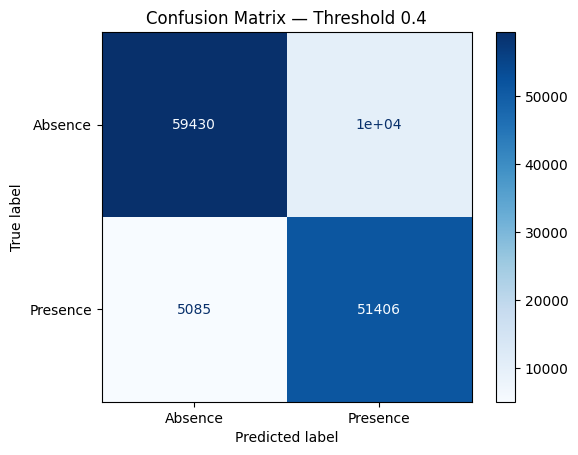

In [72]:
final_preds = (all_probs >= 0.4).astype(int)

cm = confusion_matrix(y_test, final_preds)
ConfusionMatrixDisplay(cm, display_labels=['Absence', 'Presence']).plot(cmap='Blues')
plt.title('Confusion Matrix — Threshold 0.4')
plt.show()

At threshold 0.4 — model correctly identifies 51,406 heart disease patients and only misses 5,085. False alarms (10,079) are acceptable in medical context as they lead to further testing rather than harm.

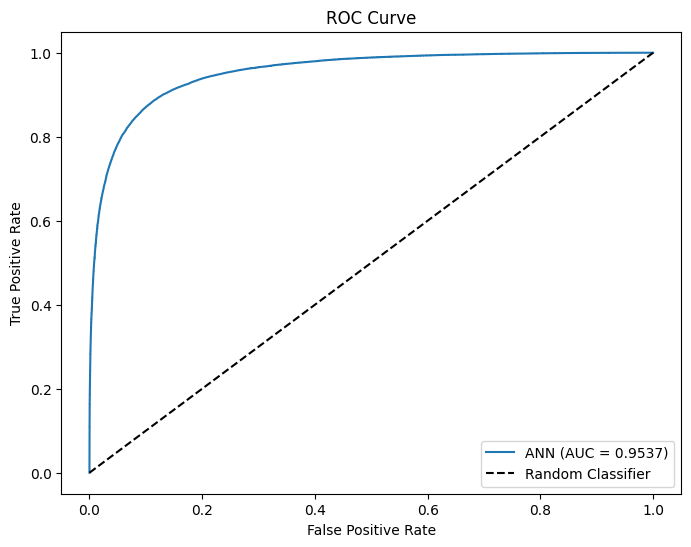

In [73]:
fpr, tpr, _ = roc_curve(y_test, all_probs)
auc = roc_auc_score(y_test, all_probs)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'ANN (AUC = {auc:.4f})')
plt.plot([0,1], [0,1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

AUC of 0.9537 — curve hugs the top left corner showing excellent discrimination between disease and non-disease patients. Far superior to the random classifier (dashed line). Model correctly ranks 95.37% of patient pairs.

## 10. Save Model
Saving trained ANN weights and preprocessor pipeline for future inference.

In [75]:
torch.save(model.state_dict(), 'heart_disease_ann.pth')
joblib.dump(preprocessor, 'preprocessor.pkl')
print("Model and preprocessor saved!")

Model and preprocessor saved!
